In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('newreg.xlsx')

In [13]:
df.rename(columns={'x': 'area', 'y': 'rent'}, inplace=True)

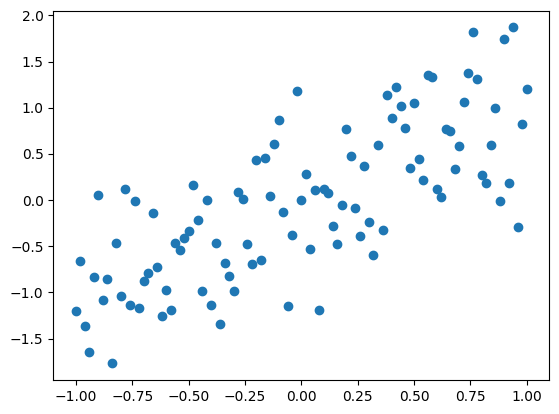

In [14]:
plt.scatter(df['area'], df['rent'])

In [15]:
df[['area']].shape # reshape the data to two dimensions

(101, 1)

In [10]:
from sklearn.linear_model import LinearRegression

In [16]:
lr = LinearRegression()

In [17]:
x = df[['area']] # it should in 2D format
y = df['rent']

In [18]:
model = lr.fit(x,y)

In [19]:
model.predict([[0.33]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([0.31795457])

In [20]:
yp = model.predict(x).round(2)

In [21]:
y

,rent
0,-1.20
1,-0.66
2,-1.36
3,-1.65
4,-0.83
...,...
96,0.19
97,1.87
98,-0.29
99,0.82


In [22]:
yp

array([-1.08, -1.06, -1.03, -1.01, -0.99, -0.97, -0.95, -0.93, -0.91,
       -0.89, -0.87, -0.85, -0.82, -0.8 , -0.78, -0.76, -0.74, -0.72,
       -0.7 , -0.68, -0.66, -0.64, -0.61, -0.59, -0.57, -0.55, -0.53,
       -0.51, -0.49, -0.47, -0.45, -0.43, -0.41, -0.38, -0.36, -0.34,
       -0.32, -0.3 , -0.28, -0.26, -0.24, -0.22, -0.2 , -0.17, -0.15,
       -0.13, -0.11, -0.09, -0.07, -0.05, -0.03, -0.01,  0.01,  0.03,
        0.06,  0.08,  0.1 ,  0.12,  0.14,  0.16,  0.18,  0.2 ,  0.22,
        0.24,  0.27,  0.29,  0.31,  0.33,  0.35,  0.37,  0.39,  0.41,
        0.43,  0.45,  0.48,  0.5 ,  0.52,  0.54,  0.56,  0.58,  0.6 ,
        0.62,  0.64,  0.66,  0.68,  0.71,  0.73,  0.75,  0.77,  0.79,
        0.81,  0.83,  0.85,  0.87,  0.89,  0.92,  0.94,  0.96,  0.98,
        1.  ,  1.02])

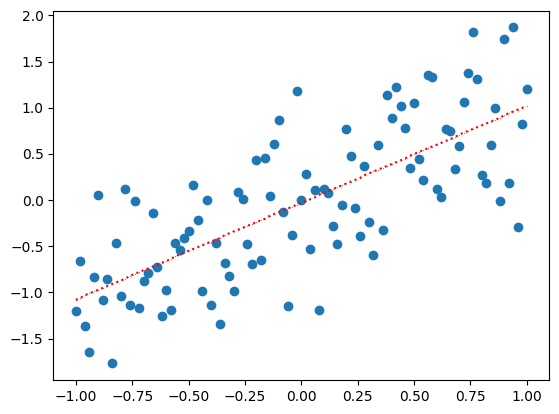

In [24]:
plt.scatter(df['area'], df['rent'])
plt.plot(df['area'], yp, '*r:', ms=0.1)

# Evaluation

In [55]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [30]:
mean_squared_error(y, yp)

0.31098415841584154

In [56]:
r2_score(y, yp)

0.5457607652005615

In [57]:
mean_absolute_percentage_error(y, yp)

22295047660253.336

# Lets take few samples only

In [25]:
newdf = df.sample(10)

In [26]:
newdf

,area,rent
73,0.46,0.78
54,0.08,-1.19
42,-0.16,0.46
38,-0.24,-0.48
69,0.38,1.14
91,0.82,0.18
55,0.10,0.12
3,-0.94,-1.65
83,0.66,0.75
100,1.00,1.20


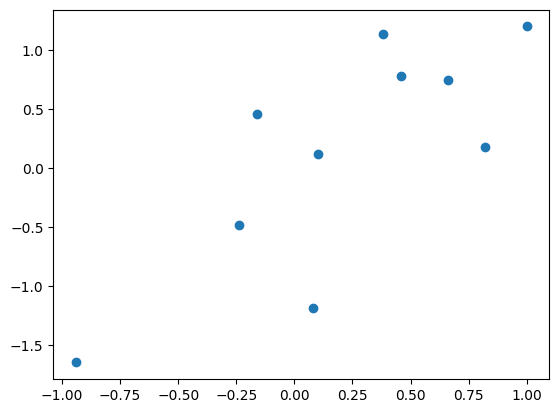

In [28]:
plt.scatter(newdf['area'], newdf['rent'])


# Lets try with Decision Tree

In [32]:
from sklearn.tree import DecisionTreeRegressor

In [124]:
dt_model = DecisionTreeRegressor()

In [125]:
dt_model.fit(x,y)

DecisionTreeRegressor()

In [126]:
dt_yp = dt_model.predict(x)

In [127]:
mean_squared_error(y, dt_yp)

0.0

In [128]:
r2_score(y, dt_yp)

1.0

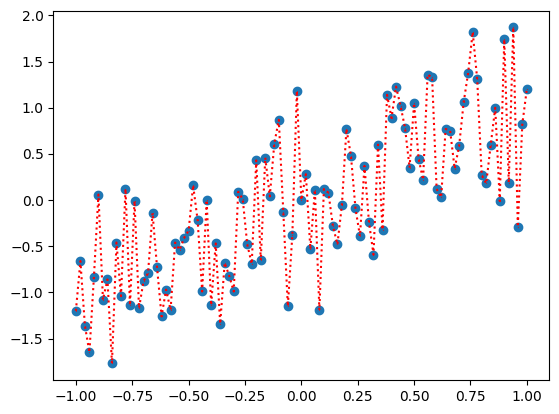

In [129]:
plt.scatter(df['area'], df['rent'])
plt.plot(df['area'], dt_yp, '*r:', ms=0.1)

# KNN modelling technique

In [44]:
from sklearn.neighbors import KNeighborsRegressor

In [88]:
kn_model = KNeighborsRegressor(n_neighbors=21)

In [89]:
kn_model.fit(x,y)

KNeighborsRegressor(n_neighbors=21)

In [90]:
kn_yp = kn_model.predict(x)

In [91]:
mean_squared_error(y, kn_yp)

0.30891650165016504

In [92]:
r2_score(y, kn_yp)

0.5487808895433999

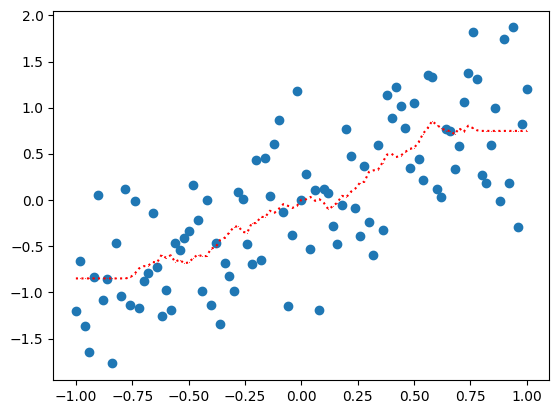

In [93]:
plt.scatter(df['area'], df['rent'])
plt.plot(df['area'], kn_yp, '*r:', ms=0.1)

# SVM Regression

In [50]:
from sklearn.svm import SVR

In [51]:
sv_model = SVR()

In [52]:
sv_model.fit(x,y)

SVR()

In [53]:
sv_yp = sv_model.predict(x)

In [54]:
mean_squared_error(y, sv_yp)

0.3093485033204239

In [60]:
r2_score(y, sv_yp)

0.5481498859928329

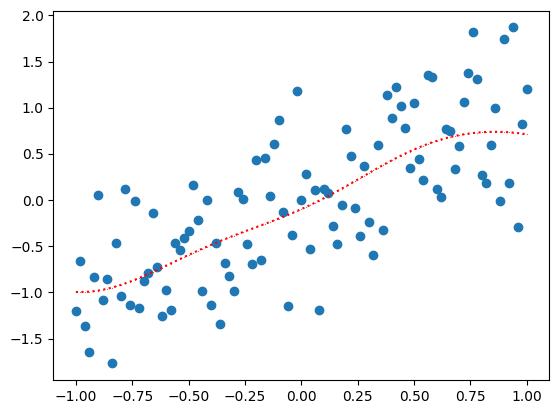

In [63]:
plt.scatter(df['area'], df['rent'])
plt.plot(df['area'], sv_yp, '*r:', ms=0.1)
#

In [130]:
df

,area,rent
0,-1.00,-1.20
1,-0.98,-0.66
2,-0.96,-1.36
3,-0.94,-1.65
4,-0.92,-0.83
...,...,...
96,0.92,0.19
97,0.94,1.87
98,0.96,-0.29
99,0.98,0.82


In [131]:
from sklearn.model_selection import train_test_split

In [147]:
# train_test_split(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j'], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [141]:
xtrain, xtest, ytrain, ytest = train_test_split(df[['area']], df['rent'])

In [142]:
xtrain.shape

(75, 1)

In [140]:
xtest.shape

(26,)

In [143]:
ytrain.shape

(75,)

In [144]:
ytest.shape

(26,)

In [154]:
model_knn = KNeighborsRegressor(n_neighbors=1)

## model with neighbours as 1

In [157]:
model_knn.fit(xtrain, ytrain)
yp_train = model_knn.predict(xtrain)
mean_squared_error(ytrain, yp_train)

0.0

In [158]:
yp_test = model_knn.predict(xtest)
mean_squared_error(ytest, yp_test)

0.6965576923076924

## model with neighbour as 21

In [159]:
model_knn2 = KNeighborsRegressor(n_neighbors=21)

In [160]:
model_knn2.fit(xtrain, ytrain)
yp_train2 = model_knn2.predict(xtrain)
mean_squared_error(ytrain, yp_train2)

0.2848751625094482

In [161]:
yp_test2 = model_knn2.predict(xtest)
mean_squared_error(ytest, yp_test2)

0.37275521541950113